# 🌲 Ensemble Models | Clase 5

**Unidad 2: Modelos Supervisados Avanzados**

Versión: 2025-1 | Modificado: 2026-04-24

Duración: 2 horas | Formato: Pregrado + Doctorado (dual)

<div style="background-color:#F8F9FA; border:2px solid #AEB6BF; padding:12px 18px; border-radius:8px; margin:10px 0;">
<strong>🎓 Modo de uso:</strong> Este notebook es compartido por dos cursos.<br><br>
<span style="color:#2E86C1; font-weight:bold;">🔵 Pregrado</span> — Trabaja el contenido general y los bloques azules. Los bloques amarillos son opcionales y te darán contexto adicional.<br><br>
<span style="color:#B7950B; font-weight:bold;">🟡 Doctorado</span> — Trabaja el contenido general y <em>ambos</em> bloques. Los bloques azules te ofrecen la intuición; los amarillos, la formalización.
</div>

## 📍 Mapa de Clase

| Sección | Tema | Tiempo |
|---------|------|--------|
| 1 | ¿Por qué combinar modelos? | 15 min |
| 2 | Voting y Averaging | 20 min |
| 3 | Bagging y Random Forest | 25 min |
| 4 | Boosting (AdaBoost, GBM, XGBoost) | 25 min |
| 5 | Stacking | 15 min |
| 6 | Experimento Comparativo | 15 min |
| 7 | Ejercicios en clase | 10 min |
| 8 | Resumen y siguiente clase | 5 min |

### Objetivos de Aprendizaje

**Pregrado:**
- Entender por qué ensamblar modelos reduce el error
- Implementar Voting, Bagging, Boosting en sklearn
- Interpretar feature importances y OOB error
- Comparar métodos en un dataset real

**Doctorado:**
- Análisis formal del error de conjunto
- Descomposición bias-varianza en bagging
- Derivación de AdaBoost y descenso de gradiente
- Riesgos de data leakage en stacking

In [1]:
# ============================================================================
# SETUP: Imports, random state, versiones
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Random state para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Versiones
print("="*70)
print("VERSIONES DE LIBRERÍAS")
print("="*70)
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost:      {xgb.__version__}")
print(f"Matplotlib:   {plt.matplotlib.__version__}")
print(f"Seaborn:      {sns.__version__}")
print("="*70)

# Configurar matplotlib y seaborn
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("\n✅ Setup completado")

VERSIONES DE LIBRERÍAS
NumPy:        2.4.4
Pandas:       3.0.2
Scikit-learn: 1.8.0
XGBoost:      3.2.0
Matplotlib:   3.10.8
Seaborn:      0.13.2

✅ Setup completado


## 1. ¿Por qué combinar modelos?

### La idea fundamental: "Diversidad > Especialización"

En la vida real, cuando enfrentamos una decisión importante, no consultamos a *una* sola persona experta. Consultamos a un **comité de expertos** que debaten y votan. ¿Por qué funciona esto?

**La intuición:** Si tenemos N modelos "mediocres" pero diversos, y cada uno comete errores en diferentes muestras, el ensemble que vota entre ellos puede ser **mejor que cualquiera de sus componentes**.

Esto es especialmente cierto cuando:
1. Los errores de cada modelo son **independientes** (cometen errores en casos distintos)
2. Cada modelo tiene accuracy **mejor que 0.5** (mejor que lanzar una moneda)

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>
<strong>Intuición del error de mayoría:</strong> Imagina que tienes 5 clasificadores, cada uno con p=0.7 de acertar (accuracy 70%). Si sus errores son <em>independientes</em>, la mayoría estará correcta cuando al menos 3 de 5 acierten.<br><br>
Esto ocurre con probabilidad mucho mayor a 70%, ¡incluso si algunos modelos tienen accuracy más baja!<br><br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la derivación matemática? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>
<strong>Cálculo formal del error de ensemble (votación mayoritaria):</strong><br><br>
Si cada clasificador tiene error independiente con probabilidad p, y votamos mayoritariamente con N clasificadores, el error del ensemble es:<br><br>

$P(\text{error}_{\text{ensemble}}) = \sum_{k=\lceil N/2 \rceil}^{N} \binom{N}{k} p^k (1-p)^{N-k}$<br><br>

Para N grande y p < 0.5, esto decrece <em>exponencialmente</em> con N. Ejemplo: con N=21 clasificadores independientes, cada uno con p=0.3, el error ensemble cae de 30% a ~0.01%.<br><br>
<span style="font-size:0.85em; color:#7D6608;">→ El supuesto crítico es la <em>independencia</em> de errores. Si todos los modelos cometen errores en los mismos casos, no hay beneficio.</span>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import ipywidgets as widgets
from IPython.display import display

def plot_ensemble_error(N=11, p=0.30):
    # Aseguramos la mayoría simple (mitad más uno)
    majority_votes = N // 2 + 1
    
    # Eje X: Rango de probabilidades de error individual de 0 a 1
    p_values = np.linspace(0, 1, 100)
    
    # Calculamos el error del ensamble para toda la curva.
    # binom.sf (Survival Function) equivale a 1 - CDF, 
    # lo que calcula exactamente la sumatoria desde majority_votes hasta N.
    ensemble_errors = binom.sf(majority_votes - 1, N, p_values)
    
    # Calculamos el error específico para el valor 'p' seleccionado en el slider
    current_ensemble_error = binom.sf(majority_votes - 1, N, p)
    
    # --- Configuración del Gráfico ---
    plt.figure(figsize=(10, 6))
    
    # Curva del ensamble
    plt.plot(p_values, ensemble_errors, label=f'Error del Ensamble (N={N})', color='#2196F3', linewidth=2.5)
    
    # Línea de referencia (y = x)
    plt.plot(p_values, p_values, label='Error Individual sin ensamble', color='#F44336', linestyle='--')
    
    # Punto actual interactivo
    plt.scatter([p], [current_ensemble_error], color='#FF9800', s=120, zorder=5, 
                label=f'Punto Actual: p={p:.2f}')
    
    # Formato visual
    plt.title('Teorema del Jurado de Condorcet', fontsize=14, pad=15)
    plt.xlabel('Probabilidad de error individual (p)', fontsize=12)
    plt.ylabel('Probabilidad de error del ensamble', fontsize=12)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7)
    plt.legend(loc='upper left')
    plt.show()
    
    # --- Panel de Resultados ---
    print("-" * 50)
    print(f"N (Clasificadores): \t {N}")
    print(f"p (Error individual): \t {p:.2f}")
    print(f"P(Error ensamble): \t {current_ensemble_error:.4f}\n")
    
    # Conclusión dinámica
    if current_ensemble_error < p:
        print("✅ El ensamble MEJORA el rendimiento (reduce el error).")
    elif current_ensemble_error > p:
        print("❌ El ensamble EMPEORA el rendimiento (los modelos son peores que el azar).")
    else:
        print("⚖️ El ensamble rinde igual que un modelo individual.")

# Creamos los sliders interactivos
N_slider = widgets.IntSlider(value=11, min=1, max=101, step=2, description='N (Impar):')
p_slider = widgets.FloatSlider(value=0.30, min=0.0, max=1.0, step=0.01, description='p (Error):')

# Generamos la celda interactiva
widgets.interact(plot_ensemble_error, N=N_slider, p=p_slider);

interactive(children=(IntSlider(value=11, description='N (Impar):', max=101, min=1, step=2), FloatSlider(value…

Dataset Wine Cargado:
  • Muestras: 178
  • Features: 13
  • Clases: 3
  • Train set: 124
  • Test set: 54

ACCURACY INDIVIDUAL DE CADA MODELO
Decision Tree (d=3)       → 0.9630 (96.30%)
Decision Tree (d=4)       → 0.9630 (96.30%)
Naive Bayes 1             → 1.0000 (100.00%)
Logistic Reg 1            → 0.9815 (98.15%)
SVM (C=0.5)               → 0.6667 (66.67%)

Accuracy PROMEDIO de modelos base: 0.9148

VOTING MAYORITARIO (HARD)
Accuracy VOTING: 0.9815 (98.15%)
Mejora vs. promedio: +6.67%



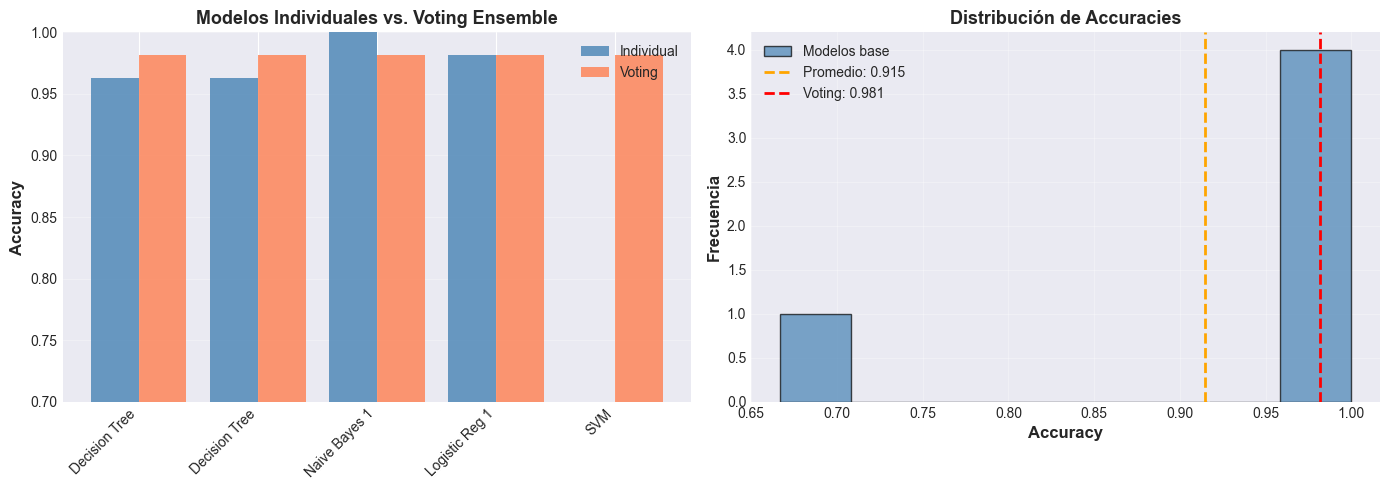

✅ Conclusión: El ensemble supera a todos los modelos individuales,
   validando el concepto de sabiduría de la multitud.


In [3]:
# ============================================================================
# Demostración numérica: 5 clasificadores mediocres voting vs individuales
# ============================================================================

# Cargar dataset wine
wine = load_wine() ## Cargamos el dataset de vinos desde sklearn, que es un dataset clásico para clasificación con 3 clases y 13 features. se encuentra en sklearn.datasets
X = pd.DataFrame(wine.data, columns=wine.feature_names) ## X es un DataFrame con las features del dataset, y le asignamos los nombres de las columnas usando wine.feature_names
y = wine.target ## target es el vector de etiquetas (clases) del dataset

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print("Dataset Wine Cargado:")
print(f"  • Muestras: {X.shape[0]}")
print(f"  • Features: {X.shape[1]}")
print(f"  • Clases: {len(np.unique(y))}")
print(f"  • Train set: {X_train.shape[0]}")
print(f"  • Test set: {X_test.shape[0]}")
print()

# Crear 5 clasificadores "mediocres" con diferentes configuraciones
modelos_base = [
    ("Decision Tree (d=3)", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
    ("Decision Tree (d=4)", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
    ("Naive Bayes 1", GaussianNB()),
    ("Logistic Reg 1", LogisticRegression(max_iter=200, random_state=RANDOM_STATE)),
    ("SVM (C=0.5)", SVC(C=0.5, random_state=RANDOM_STATE)),
]

# Entrenar y evaluar cada modelo
print("="*70)
print("ACCURACY INDIVIDUAL DE CADA MODELO")
print("="*70)

accuracies_individual = []
for nombre, modelo in modelos_base: ## Iteramos sobre cada modelo base
    modelo.fit(X_train, y_train) ## Entrenamos el modelo actual
    y_hat= modelo.predict(X_test); ## Predecimos con el modelo actual
    acc = accuracy_score(y_test,y_hat) ## Evaluamos el modelo actual
    accuracies_individual.append(acc)
    print(f"{nombre:25} → {acc:.4f} ({acc*100:.2f}%)")

print()
acc_promedio = np.mean(accuracies_individual)
print(f"Accuracy PROMEDIO de modelos base: {acc_promedio:.4f}")
print()

# Votación mayoritaria (hard voting)
voting_clf = VotingClassifier(
    estimators=modelos_base,
    voting='hard' ## Mayoría simple (hard voting)
)
voting_clf.fit(X_train, y_train) ## Entrenamos el ensemble con los modelos base
acc_voting = accuracy_score(y_test, voting_clf.predict(X_test)) ## Evaluamos el ensemble en el test set

print("="*70)
print("VOTING MAYORITARIO (HARD)")
print("="*70)
print(f"Accuracy VOTING: {acc_voting:.4f} ({acc_voting*100:.2f}%)")
print(f"Mejora vs. promedio: +{(acc_voting - acc_promedio)*100:.2f}%")
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Accuracy individual vs voting
nombres_modelos = [nombre.split('(')[0].strip() for nombre, _ in modelos_base]
x_pos = np.arange(len(nombres_modelos))

ax = axes[0]
bars1 = ax.bar(x_pos - 0.2, accuracies_individual, 0.4, label='Individual', alpha=0.8, color='steelblue')
bars2 = ax.bar(x_pos + 0.2, [acc_voting]*len(modelos_base), 0.4, label='Voting', alpha=0.8, color='coral')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Modelos Individuales vs. Voting Ensemble', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_modelos, rotation=45, ha='right')
ax.set_ylim([0.7, 1.0])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución de accuracies
ax = axes[1]
ax.hist(accuracies_individual, bins=8, alpha=0.7, edgecolor='black', color='steelblue', label='Modelos base')
ax.axvline(acc_promedio, color='orange', linestyle='--', linewidth=2, label=f'Promedio: {acc_promedio:.3f}')
ax.axvline(acc_voting, color='red', linestyle='--', linewidth=2, label=f'Voting: {acc_voting:.3f}')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Accuracies', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Conclusión: El ensemble supera a todos los modelos individuales,")
print("   validando el concepto de sabiduría de la multitud.")

## 2. Voting y Averaging: Los Fundamentos del Ensemble

### Hard Voting vs. Soft Voting

**Hard Voting:** Cada modelo emite un voto (su predicción de clase), y se toma la clase más votada.
- Simple, robusto
- No requiere probabilidades

**Soft Voting:** Cada modelo predice probabilidades para cada clase, se promedian, y se elige la clase con probabilidad promedio más alta.
- Más información (usa confianza de cada modelo)
- Mejor resultado cuando los modelos tienen buenas probabilidades

### ¿Cuándo funciona el voting?

**Condiciones necesarias:**
1. **Diversidad:** Los modelos cometen errores en diferentes casos
2. **Competencia:** Cada modelo tiene accuracy > 0.5 (mejor que azar)
3. **Descorrelación:** Idealmente, correlación baja entre errores

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>
<strong>Interpretación en términos de votos:</strong><br>
• Hard voting: 3 modelos votan → gana el que tiene más votos (democracia directa)<br>
• Soft voting: 3 modelos dan puntuaciones de confianza (0-100%) → se promedian → gana el que tiene mayor confianza promedio<br><br>
Soft voting suele ser mejor porque <em>no descarta</em> la información de confianza.
<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres saber cuándo el voting falla? Ve al bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>
<strong>Análisis de cuando el voting falla:</strong><br><br>
Si los N clasificadores están altamente correlacionados (cometen errores en los mismos casos), el voting proporciona poco o nada de mejora. Formalmente, si todos predicen la misma clase incorrecta, el error ensemble = error individual.<br><br>
<strong>Diversity-Accuracy Trade-off (Kuncheva, 2003):</strong> Para maximizar el ensemble, necesitamos que

$\text{Cov}(e_i, e_j) < 0$ (errores anticorrelacionados) o al menos $ \text{Cov}(e_i, e_j) ≈ 0 $. Si $ \text{Cov}(e_i, e_j) > 0 $,

 los modelos son redundantes.<br><br>
<span style="font-size:0.85em; color:#7D6608;">→ Esto explica por qué bagging y boosting funcionan: fuerzan la diversidad mediante resampling.</span>
</div>

VOTACIÓN EN DATASETS MULTICLASE

Accuracies de modelos BASE y VOTACIÓN:
----------------------------------------------------------------------
  DT                   → 0.9630
  GNB                  → 1.0000
  LR                   → 0.9815

  VOTING (HARD)       → 1.0000
  VOTING (SOFT)       → 1.0000

Cross-Validation (5-fold) en TRAINING SET:
----------------------------------------------------------------------
  Hard Voting: 0.9437 ± 0.0407
  Soft Voting: 0.9353 ± 0.0411



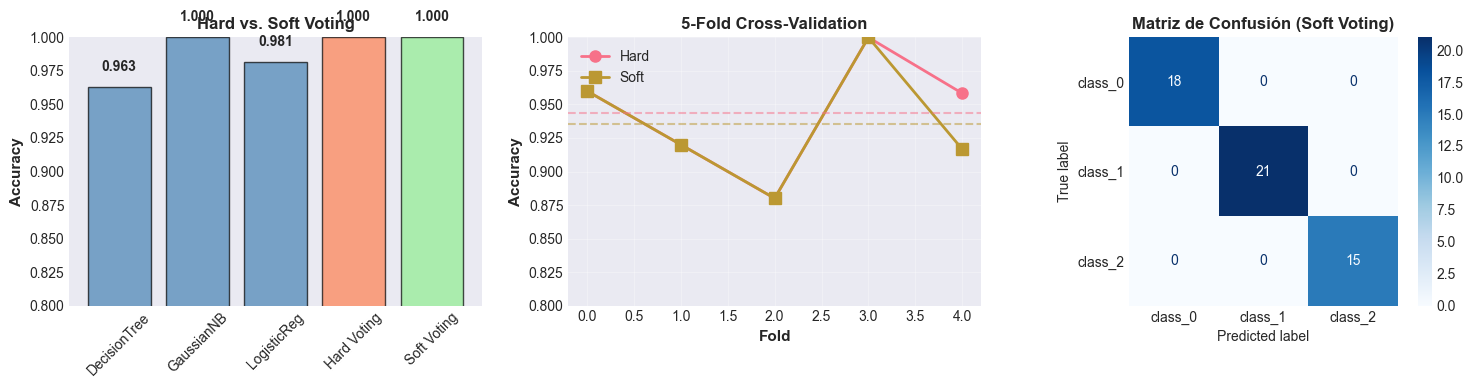

✅ Soft voting generalmente es mejor porque usa información de confianza.


In [4]:
# ============================================================================
# Hard Voting vs. Soft Voting en el dataset Wine
# ============================================================================

print("="*70)
print("VOTACIÓN EN DATASETS MULTICLASE")
print("="*70)
print()

# Crear ensemble con hard voting
voting_hard = VotingClassifier( ## begin VotingClassifier
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
        ('gnb', GaussianNB()),
        ('lr', LogisticRegression(max_iter=200, random_state=RANDOM_STATE))
    ],
    voting='hard' ## Mayoría simple (hard voting)
) ## end VotingClassifier

# Crear ensemble con soft voting
voting_soft = VotingClassifier( ## begin VotingClassifier
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
        ('gnb', GaussianNB()),
        ('lr', LogisticRegression(max_iter=200, random_state=RANDOM_STATE))
    ],
    voting='soft' ## Votación ponderada por probabilidades (soft voting)
) ## end VotingClassifier

# Entrenar
voting_hard.fit(X_train, y_train) ## recordar que fit es el entrenamiento del modelo
voting_soft.fit(X_train, y_train)

# Evaluación individual
print("Accuracies de modelos BASE y VOTACIÓN:")
print("-" * 70)

resultados = {}
for nombre, modelo in voting_hard.named_estimators_.items():
    acc = accuracy_score(y_test, modelo.predict(X_test))
    resultados[nombre] = acc
    print(f"  {nombre.upper():20} → {acc:.4f}")

acc_hard = accuracy_score(y_test, voting_hard.predict(X_test))
acc_soft = accuracy_score(y_test, voting_soft.predict(X_test))

print(f"\n  VOTING (HARD)       → {acc_hard:.4f}")
print(f"  VOTING (SOFT)       → {acc_soft:.4f}")
print()

# Cross-validation
cv_scores_hard = cross_val_score(voting_hard, X_train, y_train, cv=5)
cv_scores_soft = cross_val_score(voting_soft, X_train, y_train, cv=5)

print("Cross-Validation (5-fold) en TRAINING SET:")
print("-" * 70)
print(f"  Hard Voting: {cv_scores_hard.mean():.4f} ± {cv_scores_hard.std():.4f}")
print(f"  Soft Voting: {cv_scores_soft.mean():.4f} ± {cv_scores_soft.std():.4f}")
print()

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Comparativa de métodos
ax = axes[0]
metodos = ['DecisionTree', 'GaussianNB', 'LogisticReg', 'Hard Voting', 'Soft Voting']
accs = [resultados['dt'], resultados['gnb'], resultados['lr'], acc_hard, acc_soft]
colors = ['steelblue', 'steelblue', 'steelblue', 'coral', 'lightgreen']

bars = ax.bar(metodos, accs, color=colors, alpha=0.7, edgecolor='black')
for i, (bar, acc) in enumerate(zip(bars, accs)):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Hard vs. Soft Voting', fontsize=12, fontweight='bold')
ax.set_ylim([0.8, 1.0])
ax.tick_params(axis='x', rotation=45)
#ax.grid(axis='y', alpha=0.3)
ax.grid(False)

# Gráfico 2: Cross-validation scores
ax = axes[1]
x_pos = np.arange(len(cv_scores_hard))
ax.plot(x_pos, cv_scores_hard, 'o-', label='Hard', linewidth=2, markersize=8)
ax.plot(x_pos, cv_scores_soft, 's-', label='Soft', linewidth=2, markersize=8)
ax.axhline(cv_scores_hard.mean(), color='C0', linestyle='--', alpha=0.5)
ax.axhline(cv_scores_soft.mean(), color='C1', linestyle='--', alpha=0.5)
ax.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('5-Fold Cross-Validation', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim([0.8, 1.0])
ax.grid(alpha=0.3)

# Gráfico 3: Matriz de confusión soft voting
from sklearn.metrics import ConfusionMatrixDisplay
y_pred_soft = voting_soft.predict(X_test)
cm = confusion_matrix(y_test, y_pred_soft)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(ax=axes[2], cmap='Blues', values_format='d')
axes[2].set_title('Matriz de Confusión (Soft Voting)', fontsize=12, fontweight='bold')
### eliminar gridlines del ultimo plot
axes[2].grid(False)

plt.tight_layout()
plt.show()

print("✅ Soft voting generalmente es mejor porque usa información de confianza.")

## 3. Bagging y Random Forest: Ensemble por Bootstrap

### ¿Qué es Bagging?

**Bootstrap Aggregating (Bagging):**
1. Crear B muestras de bootstrap del training set (muestreo *con reemplazamiento*)
2. Entrenar un modelo en cada muestra
3. Agregar predicciones (votación o promedio)

**Intuición:** Es como tener B "universos alternativos" de datos. Cada modelo aprende de una realidad ligeramente distinta. Los errores de uno se compensan con aciertos de otros.

### Random Forest: Bagging + Aleatoriedad en Features

Random Forest agrega una segunda capa de aleatoriedad:
- Bagging: resampling de *muestras*
- Random Forest: además, resampling de *features* en cada split (típicamente √p features)

**Resultado:** Máxima diversidad con mínima correlación entre árboles.

### OOB Error: Validación "gratis"

En cada bootstrap, aprox. 63% de datos son usados, 37% quedan **Out-of-Bag (OOB)**. Estos OOB actúan como un validation set automático → estimación de generalización sin costo computacional.

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>
<strong>Analogía: "Cultivar muchos árboles en parcelas distintas"</strong><br><br>
Imagina que quieres aprender a predecir si una uva será dulce. Podrías:<br>
• Opción 1: Estudiar un campo (un árbol de decisión) → riesgo de aprender peculiaridades de ese campo<br>
• Opción 2: Estudiar 100 campos distintos (cada uno con composición levemente diferente de suelo), entrenar un árbol en cada uno, y luego promediar tu predicción → más robusto<br><br>
Random Forest es la opción 2: cada árbol aprende de una muestra bootstrap, y además, en cada decisión, solo mira un subconjunto de features. Esto evita que todos los árboles hagan las mismas cosas incorrectas.<br><br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres entender matemáticamente por qué bagging reduce varianza? Ve al bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>
<strong>Descomposición Bias-Varianza en Bagging:</strong><br><br>
Sea $f(x)$ el modelo ajustado en una muestra y $\hat{f}_B(x) = \frac{1}{B}\sum_{b=1}^B f_b(x)$ el predictor bagged.<br><br>
$$\text{Var}_{\text{bagged}}(x) = \frac{1}{B}\text{Var}(f(x)) + \frac{B-1}{B}\text{Cov}(f_i(x), f_j(x))$$<br><br>
Si los modelos son <em>perfectamente correlacionados</em> (Cov = Var), no hay beneficio. Si son <em>independientes</em> (Cov = 0), la varianza se reduce por factor 1/B.<br><br>
Random Forest agrega aleatoriedad en features para decorrelacionar árboles. Bootstrap + feature sampling = varianza baja, sesgo aproximadamente igual al árbol individual.<br><br>
<strong>OOB Error:</strong> Cada observación tiene ~37% chance de no estar en un bootstrap. Predecir con solo árboles donde está OOB da error insesgado ≈ test error, sin necesidad de holdout set.
<br>
<span style="font-size:0.85em; color:#7D6608;">→ Por esto Random Forest es superior a bagging simple para datos tabulares.</span>
</div>

BAGGING Y RANDOM FOREST

Resultados en TEST SET:
----------------------------------------------------------------------
  Decision Tree (d=15):  0.9630
  Bagging (100 árboles): 1.0000
  Random Forest (100):   1.0000

OOB Scores (estimación de generalización sin test set):
----------------------------------------------------------------------
  Bagging OOB:  0.9355
  RF OOB:       0.9758

✅ Notar que OOB ≈ Test accuracy (no requiere holdout set separado)



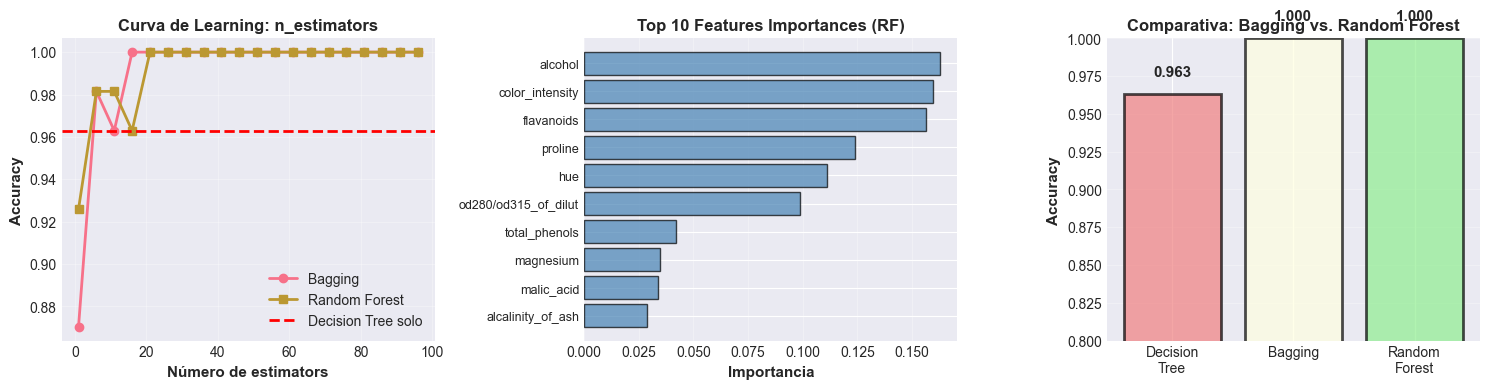

✅ Random Forest supera a Bagging: mayor diversidad por feature randomness


In [5]:
# ============================================================================
# Bagging, Random Forest, y OOB Error
# ============================================================================

print("="*70)
print("BAGGING Y RANDOM FOREST")
print("="*70)
print()

# Crear modelos
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15),
    n_estimators=100,
    random_state=RANDOM_STATE,
    oob_score=True
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_features='sqrt', ## Número de características a considerar al buscar la mejor división
    oob_score=True,
    random_state=RANDOM_STATE
)

dt_clf = DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE)

# Entrenar
dt_clf.fit(X_train, y_train)
bagging_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Evaluación en test set
acc_dt = accuracy_score(y_test, dt_clf.predict(X_test))
acc_bagging = accuracy_score(y_test, bagging_clf.predict(X_test))
acc_rf = accuracy_score(y_test, rf_clf.predict(X_test))

# OOB Scores (en training set)
oob_bagging = bagging_clf.oob_score_
oob_rf = rf_clf.oob_score_

print("Resultados en TEST SET:")
print("-" * 70)
print(f"  Decision Tree (d=15):  {acc_dt:.4f}")
print(f"  Bagging (100 árboles): {acc_bagging:.4f}")
print(f"  Random Forest (100):   {acc_rf:.4f}")
print()

print("OOB Scores (estimación de generalización sin test set):")
print("-" * 70)
print(f"  Bagging OOB:  {oob_bagging:.4f}")
print(f"  RF OOB:       {oob_rf:.4f}")
print()

print("✅ Notar que OOB ≈ Test accuracy (no requiere holdout set separado)")
print()

# ============================================================================
# Efecto de n_estimators en la accuracy
# ============================================================================

n_estimators_range = np.arange(1, 101, 5)
bagging_scores = []
rf_scores = []

for n_est in n_estimators_range:
    bg = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15),
        n_estimators=n_est,
        random_state=RANDOM_STATE
    )
    bg.fit(X_train, y_train)
    bagging_scores.append(accuracy_score(y_test, bg.predict(X_test)))

    rf = RandomForestClassifier(
        n_estimators=n_est, ## numero de arboles en el bosque
        max_depth=15, # profundidad de cada arbol
        max_features='sqrt', # si hay 100 features, cada arbol solo ve sqrt(100)=10 features al azar
        random_state=RANDOM_STATE 
    )
    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Impacto de n_estimators
ax = axes[0]
ax.plot(n_estimators_range, bagging_scores, 'o-', label='Bagging', linewidth=2, markersize=6)
ax.plot(n_estimators_range, rf_scores, 's-', label='Random Forest', linewidth=2, markersize=6)
ax.axhline(acc_dt, color='red', linestyle='--', linewidth=2, label='Decision Tree solo')
ax.set_xlabel('Número de estimators', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Curva de Learning: n_estimators', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Gráfico 2: Feature Importances
feature_importances_rf = rf_clf.feature_importances_
sorted_idx = np.argsort(feature_importances_rf)[::-1][:10]

ax = axes[1]
ax.barh(range(10), feature_importances_rf[sorted_idx], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(10))
ax.set_yticklabels([wine.feature_names[i][:20] for i in sorted_idx], fontsize=9)
ax.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Features Importances (RF)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Gráfico 3: Comparativa
ax = axes[2]
metodos = ['Decision\nTree', 'Bagging', 'Random\nForest']
accs = [acc_dt, acc_bagging, acc_rf]
colors = ['lightcoral', 'lightyellow', 'lightgreen']

bars = ax.bar(metodos, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Comparativa: Bagging vs. Random Forest', fontsize=12, fontweight='bold')
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Random Forest supera a Bagging: mayor diversidad por feature randomness")

## 4. Boosting: Aprender de los Errores Secuencialmente

### La idea: "Tutor que se enfoca en tus puntos débiles"

A diferencia de Bagging (todos los modelos son iguales), **Boosting entrena modelos secuencialmente**:
1. Entrenar modelo 1 en todos los datos
2. Ver en qué casos falla
3. Reponderar los datos: *aumentar peso* de muestras mal clasificadas
4. Entrenar modelo 2 en datos reponderados
5. Repetir hasta tener T modelos
6. Combinar: predicción final es promedio ponderado

**Resultado:** Cada nuevo modelo se enfoca en corregir los errores del anterior → **reduction del sesgo** (a costa de posible aumento de varianza).

### Tres variantes principales:

1. **AdaBoost (Adaptive Boosting):**
   - Reponderar muestras exponencialmente
   - Ponderar predicciones por accuracy de cada modelo

2. **Gradient Boosting (GBM):**
   - Entrenar modelos para predecir *residuos* (errores) del modelo anterior
   - Descenso de gradiente en espacio de modelos

3. **XGBoost (Extreme Gradient Boosting):**
   - Optimización de GBM con regularización, paralelización y handline de datos faltantes

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>
<strong>Ejemplo intuitivo de AdaBoost:</strong><br><br>
Imagina que quieres aprender a identificar vinos de buena calidad.<br>
• Primer intento (Modelo 1): Usas toda la información disponible. Aciertas en la mayoría, pero fallas en 20 casos.<br>
• Segundo intento (Modelo 2): Enfatizas los 20 casos donde fallaste (les das más peso). Ahora tu segundo clasificador se especializa en esos casos difíciles.<br>
• Tercero, cuarto, etc.: Cada nuevo modelo se enfoca en lo que los anteriores hicieron mal.<br><br>
La predicción final es un <em>promedio ponderado</em> donde los modelos más precisos pesan más.<br><br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la derivación matemática de AdaBoost? Ve al bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D; padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>
<strong>Derivación de AdaBoost (Freund & Schapire, 1997):</strong><br><br>
Inicializar pesos: $w_i^{(1)} = 1/N$ para todas las muestras i.<br><br>
Para t = 1 a T:<br>
1. Entrenar modelo débil $h_t$ minimizando error ponderado: $\epsilon_t = \sum_i w_i^{(t)} \mathbf{1}[h_t(x_i) \neq y_i]$<br>
2. Calcular peso del modelo: $\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$ (→ α_t → ∞ si $\epsilon_t → 0$)<br>
3. Actualizar pesos: $w_i^{(t+1)} = w_i^{(t)} \exp\left(-\alpha_t y_i h_t(x_i)\right)$ (↑ si error, ↓ si acierto)<br>
4. Normalizar: $w_i^{(t+1)} ← w_i^{(t+1)} / \sum_j w_j^{(t+1)}$<br><br>
Predicción final: $F(x) = \text{sign}\left(\sum_t \alpha_t h_t(x)\right)$<br><br>
<strong>Gradient Boosting:</strong> Generalización: minimizar loss L cualquiera mediante $F_t(x) = F_{t-1}(x) + \gamma h_t(x)$ donde $h_t$ ajusta los residuos $\nabla L(y, F_{t-1}(x))$.
<br>
<span style="font-size:0.85em; color:#7D6608;">→ XGBoost añade regularización L1/L2 en el objetivo y hace splits óptimos con second-order info.</span>
</div>

BOOSTING: ADABOOST, GRADIENT BOOSTING, XGBOOST

Accuracy en TEST SET:
----------------------------------------------------------------------
  Decision Tree (d=3) solo:     0.9630
  AdaBoost (100 rounds):        0.9815 (Δ = +1.85%)
  Gradient Boosting (100):      0.9630 (Δ = +0.00%)
  XGBoost (100):                1.0000 (Δ = +3.70%)

Cross-Validation (5-fold):
----------------------------------------------------------------------
  DT:       0.8700 ± 0.0721
  AdaBoost: 0.8863 ± 0.0710
  GBM:      0.9593 ± 0.0365
  XGBoost:  0.9673 ± 0.0310

Feature Importances (Gradient Boosting):
----------------------------------------------------------------------
  color_intensity           0.3125
  proline                   0.2404
  flavanoids                0.1929
  od280/od315_of_diluted_wines 0.0840
  malic_acid                0.0429



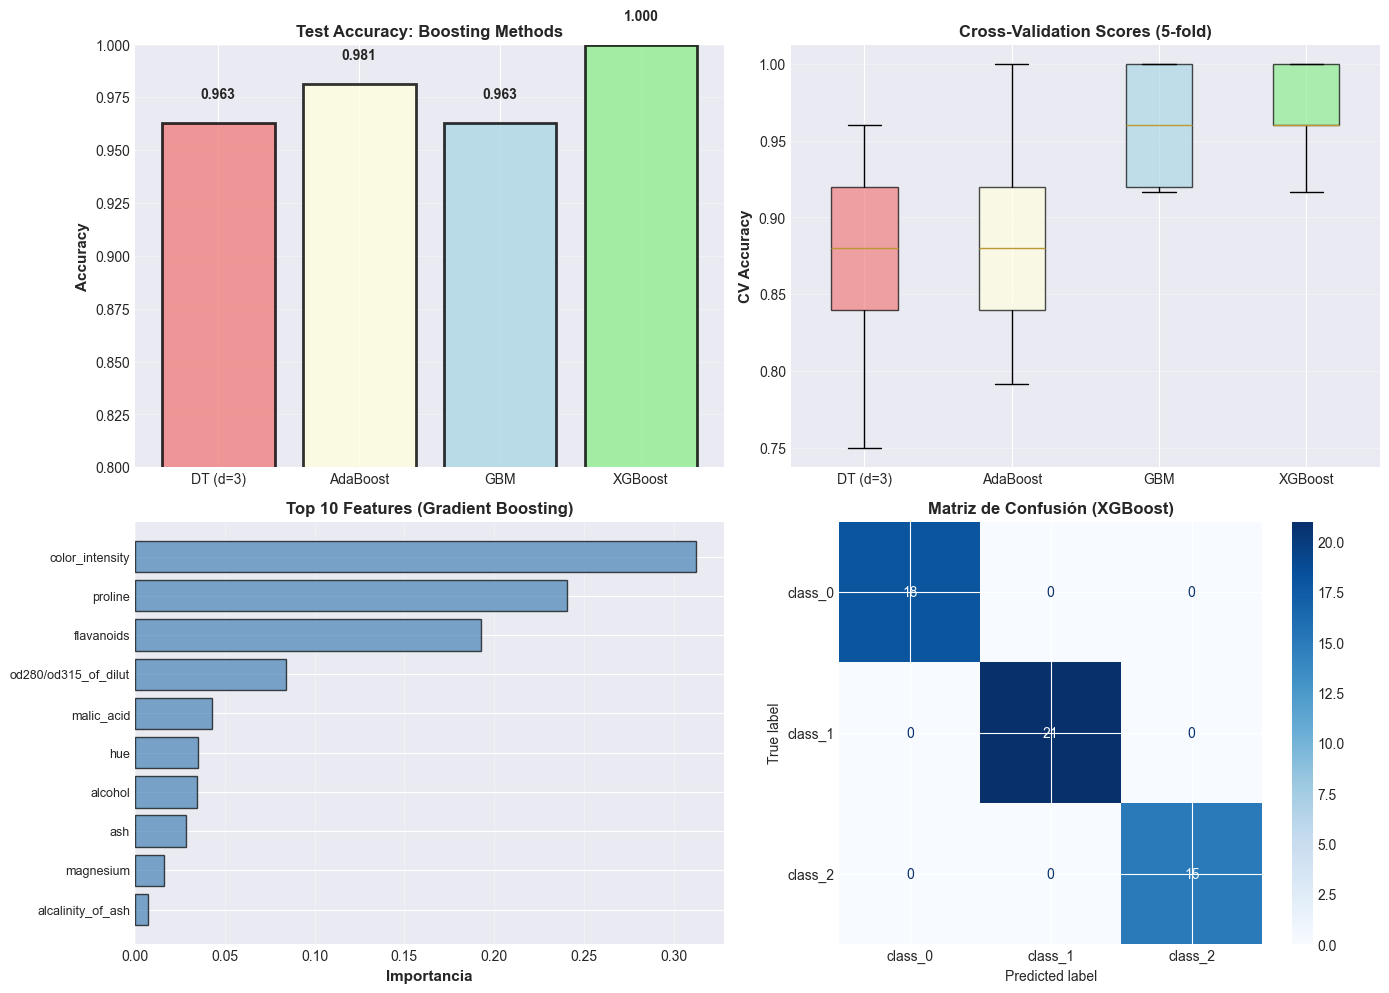

✅ XGBoost típicamente supera a GBM por regularización y optimización


In [6]:
# ============================================================================
# Boosting: AdaBoost, GBM, XGBoost en el dataset Wine
# ============================================================================

print("="*70)
print("BOOSTING: ADABOOST, GRADIENT BOOSTING, XGBOOST")
print("="*70)
print()

# Crear modelos
dt_base = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100,
    learning_rate=1.0,
    random_state=RANDOM_STATE
)

gbm_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE
)

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)

# Entrenar
dt_base.fit(X_train, y_train)
adaboost_clf.fit(X_train, y_train)
gbm_clf.fit(X_train, y_train)
xgb_clf.fit(X_train, y_train)

# Evaluación
acc_dt = accuracy_score(y_test, dt_base.predict(X_test))
acc_ada = accuracy_score(y_test, adaboost_clf.predict(X_test))
acc_gbm = accuracy_score(y_test, gbm_clf.predict(X_test))
acc_xgb = accuracy_score(y_test, xgb_clf.predict(X_test))

print("Accuracy en TEST SET:")
print("-" * 70)
print(f"  Decision Tree (d=3) solo:     {acc_dt:.4f}")
print(f"  AdaBoost (100 rounds):        {acc_ada:.4f} (Δ = {(acc_ada - acc_dt)*100:+.2f}%)")
print(f"  Gradient Boosting (100):      {acc_gbm:.4f} (Δ = {(acc_gbm - acc_dt)*100:+.2f}%)")
print(f"  XGBoost (100):                {acc_xgb:.4f} (Δ = {(acc_xgb - acc_dt)*100:+.2f}%)")
print()

# Cross-validation
print("Cross-Validation (5-fold):")
print("-" * 70)
cv_dt = cross_val_score(dt_base, X_train, y_train, cv=5)
cv_ada = cross_val_score(adaboost_clf, X_train, y_train, cv=5)
cv_gbm = cross_val_score(gbm_clf, X_train, y_train, cv=5)
cv_xgb = cross_val_score(xgb_clf, X_train, y_train, cv=5)

print(f"  DT:       {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")
print(f"  AdaBoost: {cv_ada.mean():.4f} ± {cv_ada.std():.4f}")
print(f"  GBM:      {cv_gbm.mean():.4f} ± {cv_gbm.std():.4f}")
print(f"  XGBoost:  {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")
print()

# Feature importances (GBM y XGBoost)
print("Feature Importances (Gradient Boosting):")
print("-" * 70)
importance_gbm = gbm_clf.feature_importances_
sorted_idx = np.argsort(importance_gbm)[::-1][:5]
for idx in sorted_idx:
    print(f"  {wine.feature_names[idx]:25} {importance_gbm[idx]:.4f}")
print()

# Visualización de Boosting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Comparativa test accuracy
ax = axes[0, 0]
metodos = ['DT (d=3)', 'AdaBoost', 'GBM', 'XGBoost']
accs = [acc_dt, acc_ada, acc_gbm, acc_xgb]
colors = ['lightcoral', 'lightyellow', 'lightblue', 'lightgreen']

bars = ax.bar(metodos, accs, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Test Accuracy: Boosting Methods', fontsize=12, fontweight='bold')
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Cross-validation
ax = axes[0, 1]
cv_results = [cv_dt, cv_ada, cv_gbm, cv_xgb]
x_pos = np.arange(len(metodos))
bp = ax.boxplot(cv_results, labels=metodos, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('CV Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Cross-Validation Scores (5-fold)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Gráfico 3: Feature Importances (GBM)
ax = axes[1, 0]
sorted_idx_gbm = np.argsort(importance_gbm)[::-1][:10]
ax.barh(range(10), importance_gbm[sorted_idx_gbm], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(10))
ax.set_yticklabels([wine.feature_names[i][:20] for i in sorted_idx_gbm], fontsize=9)
ax.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Features (Gradient Boosting)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Gráfico 4: Matriz de confusión XGBoost
from sklearn.metrics import ConfusionMatrixDisplay
y_pred_xgb = xgb_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(ax=axes[1, 1], cmap='Blues', values_format='d')
axes[1, 1].set_title('Matriz de Confusión (XGBoost)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ XGBoost típicamente supera a GBM por regularización y optimización")

## 5. Stacking: Meta-Learner que Aprende a Combinar

### Idea: Entrenable aprender los mejores pesos

En Voting, usamos pesos *fijos* (1/N para hard voting, probabilidades promediadas para soft).

En **Stacking**, usamos un **meta-learner** que aprende *automáticamente* qué peso dar a cada modelo base.

### Proceso:

1. **Hold-out stack set:** Dividir training en dos partes (típicamente 80-20)
2. **Entrenar base models:** En la primera parte
3. **Generar meta-features:** Predicciones de base models en la segunda parte
4. **Entrenar meta-learner:** En las meta-features (predicciones) vs. labels verdaderos
5. **Predicción:**
   - Base models predicen en test set → meta-features
   - Meta-learner combina meta-features → predicción final

In [ ]:
# ============================================================================
# Stacking con Meta-Learner
# ============================================================================

print("="*70)
print("STACKING: META-LEARNER COMBINADOR")
print("="*70)
print()

# Crear base models
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=8, random_state=RANDOM_STATE)),
    ('gnb', GaussianNB()),
]

# Meta-learner
meta_learner = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)

# Stacking CON cross-validation (recomendado)
print("Versión robusta con StackingClassifier (con cross-validation automático):")
print("-" * 70)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    cv=5,  # Usar 5-fold CV para evitar leakage
    stack_method='predict'  # O 'predict_proba' para más info
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking_cv = stacking_clf.predict(X_test)
acc_stacking_cv = accuracy_score(y_test, y_pred_stacking_cv)

print(f"Stacking (con 5-fold CV): {acc_stacking_cv:.4f}")
print()

# Comparativa
print("Comparativa de métodos (TEST SET):")
print("-" * 70)
voting_hard_test = VotingClassifier(
    estimators=base_models,
    voting='hard'
).fit(X_train, y_train)
acc_voting_test = accuracy_score(y_test, voting_hard_test.predict(X_test))

voting_soft_test = VotingClassifier(
    estimators=base_models,
    voting='soft'
).fit(X_train, y_train)
acc_voting_soft_test = accuracy_score(y_test, voting_soft_test.predict(X_test))

resultados = {
    'Decision Tree': accuracy_score(y_test, base_models[0][1].fit(X_train, y_train).predict(X_test)),
    'Hard Voting': acc_voting_test,
    'Soft Voting': acc_voting_soft_test,
    'Stacking (5-CV)': acc_stacking_cv,
}

for metodo, acc in resultados.items():
    print(f"  {metodo:25} {acc:.4f}")
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparativa
ax = axes[0]
metodos_list = list(resultados.keys())
accs_list = list(resultados.values())
colors_list = ['lightcoral', 'lightyellow', 'lightblue', 'lightgreen']

bars = ax.bar(metodos_list, accs_list, color=colors_list, alpha=0.8, edgecolor='black', linewidth=2)
for bar, acc in zip(bars, accs_list):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Comparativa: Voting vs. Stacking', fontsize=12, fontweight='bold')
ax.set_ylim([0.85, 0.98])
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Feature importance del meta-learner
ax = axes[1]
meta_weights = np.abs(stacking_clf.final_estimator_.coef_[0])  # Tomar valor absoluto de coeficientes
meta_weights_norm = meta_weights / meta_weights.sum()

base_model_names = [name for name, _ in base_models]
bars = ax.bar(base_model_names, meta_weights_norm, color=['steelblue', 'steelblue', 'steelblue'],
              alpha=0.7, edgecolor='black', linewidth=2)
for bar, weight in zip(bars, meta_weights_norm):
    ax.text(bar.get_x() + bar.get_width()/2, weight + 0.02, f'{weight:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Peso (normalizado)', fontsize=11, fontweight='bold')
ax.set_title('Pesos aprendidos del Meta-Learner', fontsize=12, fontweight='bold')
ax.set_ylim([0, 0.5])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ El meta-learner aprende a ponderar cada modelo base automáticamente")

## 6. Experimento Comparativo Global

Comparar todos los métodos en el mismo dataset con validación cruzada.

In [ ]:
# ============================================================================
# Comparativa global de TODOS los métodos
# ============================================================================

print("="*70)
print("EXPERIMENTO COMPARATIVO: TODOS LOS MÉTODOS")
print("="*70)
print()

# Definir todos los métodos
metodos_dict = {
    'Decision Tree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Decision Tree (d=10)': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Bagging (100)': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10),
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE),
    'AdaBoost (100)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100,
        learning_rate=1.0,
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    'Voting (Hard)': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)),
            ('gnb', GaussianNB()),
        ],
        voting='hard'
    ),
    'Voting (Soft)': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)),
            ('gnb', GaussianNB()),
        ],
        voting='soft'
    ),
    'Stacking': StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)),
            ('gnb', GaussianNB()),
        ],
        final_estimator=LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
        cv=5
    ),
}

# Cross-validation
cv_scores = {}
print("Cross-Validation (5-fold) en TRAINING SET:")
print("-" * 70)

for metodo, clf in metodos_dict.items():
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[metodo] = scores
    print(f"{metodo:30} {scores.mean():.4f} ± {scores.std():.4f}")

print()

# Train y test
print("Train vs Test Accuracy:")
print("-" * 70)

train_accs = {}
test_accs = {}

for metodo, clf in metodos_dict.items():
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    train_accs[metodo] = train_acc
    test_accs[metodo] = test_acc

    print(f"{metodo:30} Train: {train_acc:.4f} | Test: {test_acc:.4f}")

print()

# Crear tabla resumen
print("="*70)
print("TABLA RESUMEN (Ordenado por Test Accuracy)")
print("="*70)

resumen_df = pd.DataFrame({
    'Método': list(metodos_dict.keys()),
    'Train Acc': list(train_accs.values()),
    'Test Acc': list(test_accs.values()),
    'CV Mean': [cv_scores[m].mean() for m in metodos_dict.keys()],
    'CV Std': [cv_scores[m].std() for m in metodos_dict.keys()],
})

resumen_df = resumen_df.sort_values('Test Acc', ascending=False).reset_index(drop=True)
print(resumen_df.to_string(index=True))
print()

print("✅ Experimento comparativo completado")

## 7. Ejercicios en Clase

### Ejercicio 1 (Sin Computador - 5 min)

**Escenario:** Tienes 5 clasificadores binarios que predicen si un vino es "bueno" (1) o "malo" (0). En una muestra de test particular:

| Clasificador | Predicción | Confianza |
|---|---|---|
| Modelo A | 1 | 0.95 |
| Modelo B | 1 | 0.72 |
| Modelo C | 0 | 0.60 |
| Modelo D | 1 | 0.85 |
| Modelo E | 0 | 0.55 |

**Preguntas:**
1. ¿Cuál es el resultado de **hard voting**?
2. ¿Cuál es el resultado de **soft voting**?
3. Si la etiqueta verdadera es 1, ¿cuál método se equivocó?

### Ejercicio 2 (Con Computador - 10 min)

Modificar el Random Forest para experimentar con el parámetro `max_features`.
Graficar cómo afecta a la accuracy:

In [ ]:
# ============================================================================
# EJERCICIO 2: Impacto de max_features en Random Forest
# ============================================================================

print("="*70)
print("EJERCICIO 2: Tuning de max_features en Random Forest")
print("="*70)
print()

max_features_options = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
rf_accuracies = []
rf_train_accs = []

print("Evaluando diferentes valores de max_features:")
print("-" * 70)

for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        max_features=mf,
        random_state=RANDOM_STATE
    )
    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))

    rf_accuracies.append(test_acc)
    rf_train_accs.append(train_acc)

    print(f"  max_features={str(mf):6} → Train: {train_acc:.4f} | Test: {test_acc:.4f}")

print()

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(max_features_options))
ax.plot(x_pos, rf_train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax.plot(x_pos, rf_accuracies, 's-', label='Test Accuracy', linewidth=2, markersize=8)

ax.fill_between(x_pos, rf_train_accs, rf_accuracies, alpha=0.2, color='gray')

ax.set_xticks(x_pos)
ax.set_xticklabels(max_features_options)
ax.set_xlabel('max_features', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Impacto de max_features en Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()

print("✅ Analizar: ¿Qué max_features da mejor balance entre train y test?")
print("   (Más features = menos aleatoriedad = modelos más correlacionados)")

## 8. Resumen y Siguiente Clase

### Resumen de Métodos de Ensemble

| Método | Intuición | Cuándo usar | Ventaja principal |
|--------|-----------|-------------|------------------|
| **Hard Voting** | N modelos votan → mayoría gana | Rápido, sin probabilidades | Simplicidad |
| **Soft Voting** | Promediar probabilidades | Modelos con buenas probs | Mejor que hard |
| **Bagging** | Bootstrap múltiples → promediar | Modelos de alta varianza (ej. árboles) | Reduce varianza |
| **Random Forest** | Bagging + feature randomness | Datos tabulares, clasificación | Balance: sesgo-varianza |
| **AdaBoost** | Modelos secuenciales, pesar errores | Datos pequeños-medianos | Reduce sesgo |
| **Gradient Boosting** | Ajustar residuos iterativamente | Máxima accuracy | Mejor que AdaBoost |
| **XGBoost** | GBM + regularización | Competiciones, datos grandes | Velocidad + precisión |
| **Stacking** | Meta-learner combina predicciones | Cuando tienes modelos diversos | Máxima flexibilidad |

### Conexión con Siguiente Clase (Clase 6)

**Siguiente tema: Selección de Modelos y Tuning de Hiperparámetros**
- GridSearchCV y RandomSearchCV
- Validación cruzada estratificada
- Métricas más allá de accuracy (precisión, recall, F1, AUC)
- Curvas de aprendizaje
- Análisis de sesgo vs. varianza

**¿Por qué es importante?**
Un ensemble potente es inútil si no lo tuneamos correctamente. La siguiente clase te enseñará a encontrar la combinación óptima de hiperparámetros.

---

### Lecturas Recomendadas

**Pregrado:**
- Scikit-learn documentation: Ensemble methods (https://scikit-learn.org/stable/modules/ensemble.html)
- "Understanding Machine Learning: From Theory to Algorithms" - Capítulo 10 (Ensemble Methods)

**Doctorado:**
- Breiman, L. (1996). "Bagging predictors." Machine Learning.
- Freund, Y., & Schapire, R. E. (1997). "A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting." Journal of Computer and System Sciences.
- Chen, T., & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System." KDD.
- Wolpert, D. H. (1992). "Stacked Generalization." Neural Networks.

---

**Versión:** 2025-1 | **Modificado:** 2026-04-24

**Formato:** Pregrado + Doctorado (Dual)